# Task 1: Measure latency vs batch size

In [1]:
!pip install transformers torch matplotlib -q

In [2]:
import torch
import time
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel

In [3]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [4]:
text = "This is a simple sentence for testing model inference on CPU."

inputs_single = tokenizer(
    text,
    return_tensors="pt",
    padding=True,
    truncation=True
)

print(inputs_single)

{'input_ids': tensor([[  101,  2023,  2003,  1037,  3722,  6251,  2005,  5604,  2944, 28937,
          2006, 17368,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [8]:
batch_sizes = [1, 2, 4, 8]

total_times = []
time_per_sample = []

for batch_size in batch_sizes:

    texts = [text] * batch_size

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    with torch.no_grad():
        model(**inputs)

    # Measure inference time
    start_time = time.time()

    with torch.no_grad():
        model(**inputs)

    end_time = time.time()

    total_time = end_time - start_time
    per_sample = total_time / batch_size

    total_times.append(total_time)
    time_per_sample.append(per_sample)

    print(f"Batch Size: {batch_size}")
    print(f"Total Time: {total_time:.4f} seconds")
    print(f"Time per Sample: {per_sample:.4f} seconds")
    print("-" * 40)

Batch Size: 1
Total Time: 0.0848 seconds
Time per Sample: 0.0848 seconds
----------------------------------------
Batch Size: 2
Total Time: 0.1102 seconds
Time per Sample: 0.0551 seconds
----------------------------------------
Batch Size: 4
Total Time: 0.1901 seconds
Time per Sample: 0.0475 seconds
----------------------------------------
Batch Size: 8
Total Time: 0.3342 seconds
Time per Sample: 0.0418 seconds
----------------------------------------


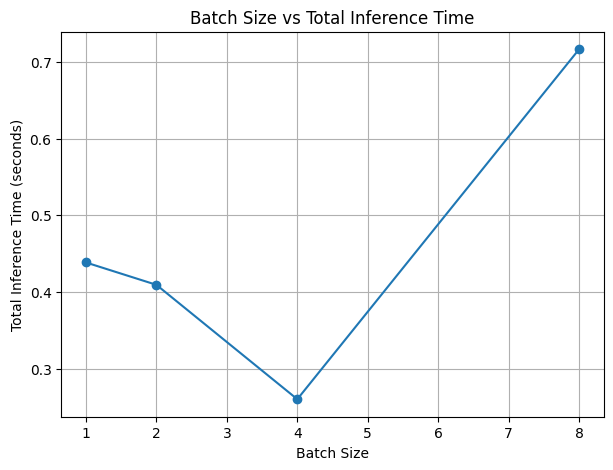

In [6]:
plt.figure(figsize=(7,5))

plt.plot(batch_sizes, total_times, marker='o')

plt.xlabel("Batch Size")
plt.ylabel("Total Inference Time (seconds)")
plt.title("Batch Size vs Total Inference Time")

plt.grid(True)
plt.show()

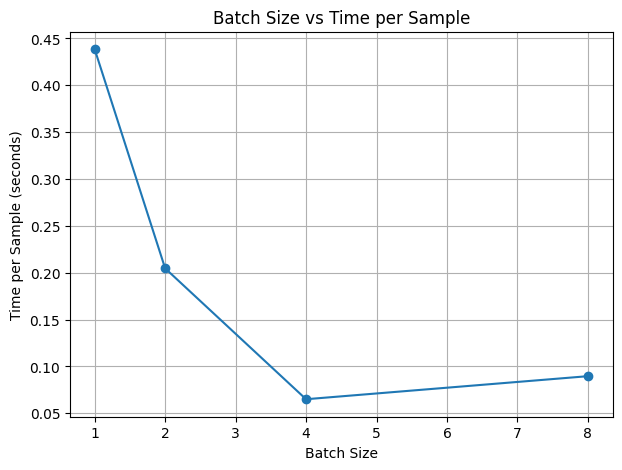

In [7]:
plt.figure(figsize=(7,5))

plt.plot(batch_sizes, time_per_sample, marker='o')

plt.xlabel("Batch Size")
plt.ylabel("Time per Sample (seconds)")
plt.title("Batch Size vs Time per Sample")

plt.grid(True)
plt.show()

**Batch size increase zala ki total inference time pan increase hoto, karan model la jast samples process karave lagtat. Pan per sample time decrease hoto, karan ekach batch madhe multiple samples ekatra process kele jatat. Yavarun samajta ki batching mule CPU inference efficiency improve hou shakte.**

# Task 2: Implement basic quantization (CPU friendly)

In [12]:
import os

In [38]:
torch.save(model.state_dict(), "original_model.pth")  #model.state_dict() -> model che learned weight det

original_size = os.path.getsize("original_model.pth") / (1024 * 1024) #os.path.getsize -> bytes madhe det tyala mb madhe convert krtoy

print(f"Original model size: {original_size:.2f} MB")

Original model size: 253.19 MB


In [39]:
quantized_model = torch.quantization.quantize_dynamic(  #Ye PyTorch ka function hai jo model ke kuch layers ko lower precision mein convert karke model ko smaller aur CPU inference ke liye more efficient banata hai.
    model,
    {torch.nn.Linear},
    dtype=torch.qint8 #8 bit quantize
)

quantized_model.eval()

print("Quantization completed.")

/tmp/ipykernel_1911/2665081736.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(  #Ye PyTorch ka function hai jo model ke kuch layers ko lower precision mein convert karke model ko smaller aur CPU inference ke liye more efficient banata hai.


Quantization completed.


In [40]:
torch.save(quantized_model.state_dict(), "quantized_model.pth")

quantized_size = os.path.getsize("quantized_model.pth") / (1024 * 1024)

print(f"Quantized model size: {quantized_size:.2f} MB")

Quantized model size: 131.72 MB


In [41]:
size_reduction = ((original_size - quantized_size) / original_size) * 100 # precentage calculate kela ki kiti % reeduce jala

print(f"Original size: {original_size:.2f} MB")
print(f"Quantized size: {quantized_size:.2f} MB")
print(f"Size reduction: {size_reduction:.2f}%")

Original size: 253.19 MB
Quantized size: 131.72 MB
Size reduction: 47.98%


In [42]:
with torch.inference_mode():
    model(**inputs)

start_time = time.time()

with torch.inference_mode():
    model(**inputs)

end_time = time.time()

original_time = end_time - start_time

print(f"Original model time: {original_time:.6f} seconds")

Original model time: 0.216203 seconds


In [43]:
with torch.inference_mode():
    quantized_model(**inputs)

start_time = time.time()

with torch.inference_mode():
    quantized_model(**inputs)

end_time = time.time()

quantized_time = end_time - start_time

print(f"Quantized model time: {quantized_time:.6f} seconds")

Quantized model time: 0.128081 seconds


In [44]:
print("----- Final Comparison -----")
print(f"Original Model Size: {original_size:.2f} MB")
print(f"Quantized Model Size: {quantized_size:.2f} MB")
print(f"Original Inference Time: {original_time:.6f} seconds")
print(f"Quantized Inference Time: {quantized_time:.6f} seconds")

----- Final Comparison -----
Original Model Size: 253.19 MB
Quantized Model Size: 131.72 MB
Original Inference Time: 0.216203 seconds
Quantized Inference Time: 0.128081 seconds


In [45]:
sample_texts = [
    "This is a simple sentence.",
    "Machine learning is useful for many applications.",
    "We are testing inference performance on CPU.",
    "Quantization can reduce model size.",
    "This is another sample for testing."
]

original_times = []
quantized_times = []

for sample in sample_texts:

    sample_input = tokenizer(
        sample,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    # Original model
    start = time.time()

    with torch.inference_mode():
        model(**sample_input)

    original_times.append(time.time() - start)

    # Quantized model
    start = time.time()

    with torch.inference_mode():
        quantized_model(**sample_input)

    quantized_times.append(time.time() - start)

print(f"Average Original Time: {sum(original_times)/len(original_times):.6f} seconds")
print(f"Average Quantized Time: {sum(quantized_times)/len(quantized_times):.6f} seconds")

Average Original Time: 0.047553 seconds
Average Quantized Time: 0.016674 seconds


** Quantization ke baad model ka size reduce ho gaya aur CPU inference speed bhi improve ho sakti hai. Maine code ko baar-baar run kiya, aur original aur quantized dono models ka inference time gradually kam hota dikha, because first run mein extra overhead hota hai and later runs mein model warm ho jata hai. Overall, quantization memory usage kam karne aur CPU inference ko efficient banane mein help karta hai.**